                                          МИНИСТЕРСТВО НАУКИ И ВЫСШЕГО ОБРАЗОВАНИЯ РФ
                                     фЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБРАЗОВАТЕЛЬНОЕ
                                                УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
                                   РОСТОВСКИЙ ГОСУДАРСТВЕННЫЙ ЭКОНОМИЧЕСКИЙ УНИВЕРСИТЕТ (РИНХ)




                                                      Методы машинного обучения
                                                        Лабораторная работа №5

                                                                           
                                                                            
                                                                             
                                                                              
                                                                              Работу выполнил студент        
                                                                                      Группы ПИ-811
                                                                                        Бойко В.А.


https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Current-Year-To-Date-/5uac-w243

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('NYPD.csv')
df

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,304027469,116,QUEENS,04/01/2025,08:30:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,BLACK,F,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0)
1,312320890,46,BRONX,09/03/2025,22:06:00,09/03/2025,22:16:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,0,0,0.000000,0.000000,"(0.0, 0.0)",POINT (0 0)
2,303250435,13,MANHATTAN,03/20/2025,00:30:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,WHITE,M,988886,207857,40.737203,-73.983273,"(40.7372030985741, -73.9832725981497)",POINT (-73.9832725981497 40.7372030985741)
3,307271594,47,BRONX,03/05/2025,17:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,BLACK,F,1026480,262584,40.887314,-73.847272,"(40.8873136344706, -73.8472717577564)",POINT (-73.8472717577564 40.8873136344706)
4,299744592,121,STATEN ISLAND,01/20/2025,18:30:00,01/20/2025,18:35:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,D,938881,167697,40.626859,-74.163440,"(40.626859, -74.16344)",POINT (-74.16344 40.626859)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438551,305451239,121,STATEN ISLAND,04/27/2025,18:46:00,04/27/2025,18:56:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,D,938881,167697,40.626859,-74.163440,"(40.626859, -74.16344)",POINT (-74.16344 40.626859)
438552,303035413,121,STATEN ISLAND,03/17/2025,08:30:00,03/17/2025,20:40:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,D,950640,160663,40.607605,-74.121046,"(40.607605, -74.121046)",POINT (-74.121046 40.607605)
438553,299625094,122,STATEN ISLAND,01/17/2025,14:30:00,01/17/2025,14:40:00,COMPLETED,(null),NaN,...,NaN,<18,WHITE HISPANIC,F,952254,148186,40.573363,-74.115173,"(40.573363, -74.115173)",POINT (-74.115173 40.573363)
438554,306469176,122,STATEN ISLAND,05/15/2025,08:00:00,05/15/2025,08:15:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,ASIAN / PACIFIC ISLANDER,E,954827,148519,40.574286,-74.105914,"(40.5742856881925, -74.1059144051212)",POINT (-74.1059144051212 40.5742856881925)


In [17]:
df.describe()

,ADDR_PCT_CD,HOUSING_PSA,JURISDICTION_CODE,KY_CD,PD_CD,TRANSIT_DISTRICT,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,438556.000000,27186.000000,438556.000000,438556.000000,438313.000000,26258.000000,4.385560e+05,438556.000000,438556.000000,438556.000000
mean,63.516265,10976.441772,0.521664,302.756337,429.627718,16.645251,9.990156e+05,206612.516823,40.467576,-73.432836
std,34.940599,21578.842193,4.656181,159.068140,233.599434,12.914274,8.430337e+04,34518.149918,3.306149,5.997988
min,1.000000,218.000000,0.000000,101.000000,100.000000,1.000000,0.000000e+00,0.000000,0.000000,-74.254378
25%,40.000000,477.000000,0.000000,118.000000,259.000000,3.000000,9.912020e+05,184894.000000,40.674120,-73.973244
50%,62.000000,741.000000,0.000000,341.000000,397.000000,12.000000,1.005020e+06,206948.000000,40.734689,-73.923737
75%,101.000000,3924.000000,0.000000,351.000000,638.000000,32.000000,1.017823e+06,235814.000000,40.813898,-73.876725
max,123.000000,73862.000000,97.000000,678.000000,922.000000,34.000000,1.067185e+06,271819.000000,40.912722,0.000000


In [18]:
df.isnull().sum().sum()

np.int64(844239)

Удаление записей с некорректными координатами

In [19]:
# удаляем явные нули
df_clean = df[(df['Latitude'] != 0.0) & (df['Longitude'] != 0.0)].copy()

In [20]:
# удаляем записи, где широта/долгота явно вне границ Нью-Йорка
# границы NYC: lat ~40.5-40.9, lon ~-74.26 - -73.7

nyc_lat_min, nyc_lat_max = 40.5, 40.9
nyc_lon_min, nyc_lon_max = -74.26, -73.7
df_clean = df_clean[
    (df_clean['Latitude'].between(nyc_lat_min, nyc_lat_max)) &
    (df_clean['Longitude'].between(nyc_lon_min, nyc_lon_max))
]

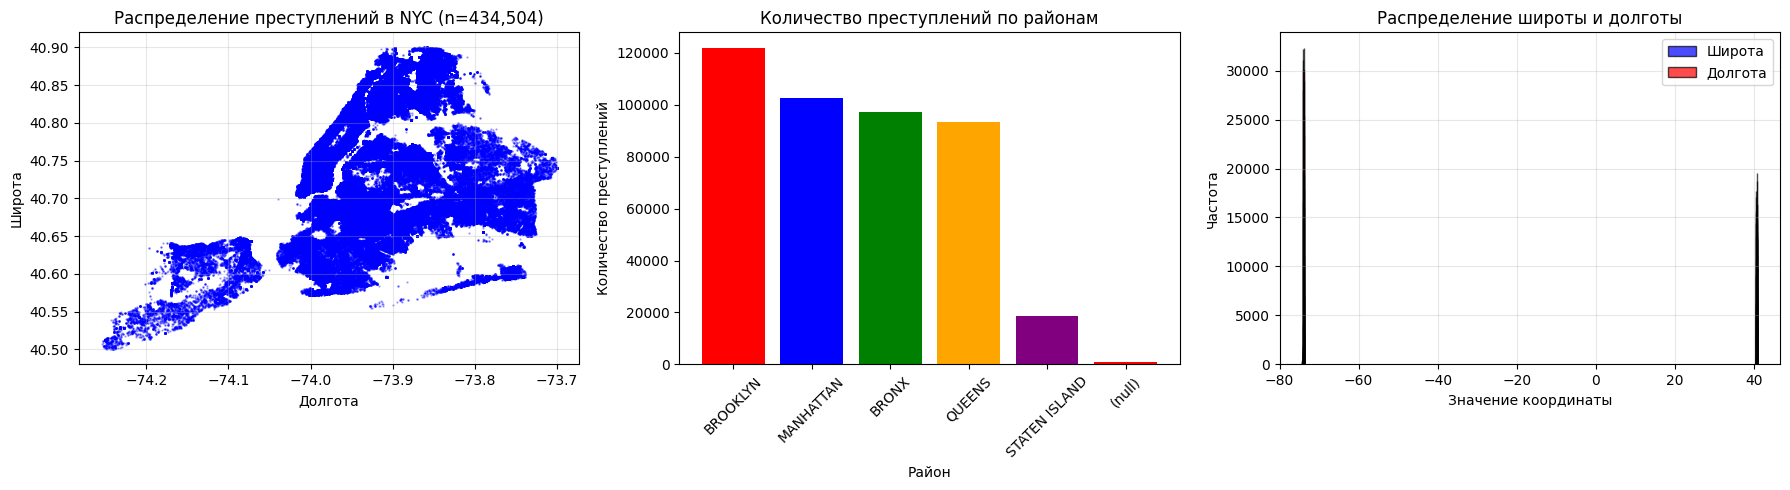

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Карта всех точек
axes[0].scatter(df_clean['Longitude'], df_clean['Latitude'],
                s=0.5, alpha=0.3, c='blue')
axes[0].set_xlabel('Долгота')
axes[0].set_ylabel('Широта')
axes[0].set_title(f'Распределение преступлений в NYC (n={len(df_clean):,})')
axes[0].grid(True, alpha=0.3)

# Разбивка по районам (BORO_NM)
boro_counts = df_clean['BORO_NM'].value_counts()
colors = ['red', 'blue', 'green', 'orange', 'purple']
axes[1].bar(boro_counts.index, boro_counts.values, color=colors)
axes[1].set_xlabel('Район')
axes[1].set_ylabel('Количество преступлений')
axes[1].set_title('Количество преступлений по районам')
axes[1].tick_params(axis='x', rotation=45)

axes[2].hist(df_clean['Latitude'], bins=50, alpha=0.7,
             label='Широта', color='blue', edgecolor='black')
axes[2].hist(df_clean['Longitude'], bins=50, alpha=0.7,
             label='Долгота', color='red', edgecolor='black')
axes[2].set_xlabel('Значение координаты')
axes[2].set_ylabel('Частота')
axes[2].set_title('Распределение широты и долготы')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Подготовка к кластеризация 

In [22]:
# Берем только координаты
X = df_clean[['Latitude', 'Longitude']].values

In [23]:
# Стандартизация (ВАЖНО для K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(434504, 2)

Кластеризация методом DBSCAN и тестировка разных комбинаций параметров

In [28]:
sample_size = min(10000, len(X_scaled))  # Максимум 10,000 точек для быстрой работы
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print(f"Используем подвыборку: {sample_size} точек из {len(X_scaled)} ({sample_size/len(X_scaled)*100:.1f}%)")

Используем подвыборку: 10000 точек из 434504 (2.3%)


Быстрый подбор eps на подвыборке

In [29]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

k_for_eps = 50  # min_samples значение для подбора
neigh = NearestNeighbors(n_neighbors=k_for_eps)
neigh.fit(X_sample)
distances, indices = neigh.kneighbors(X_sample)
k_distances = np.sort(distances[:, k_for_eps-1])

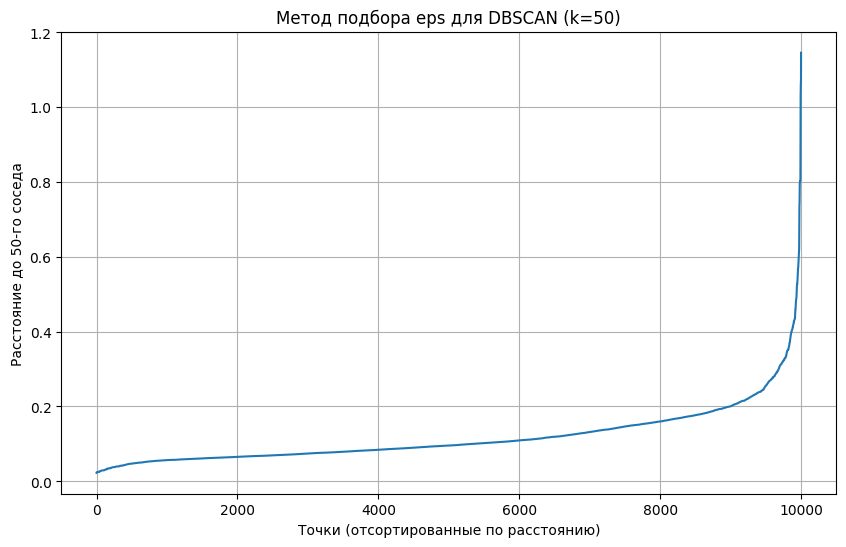

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(k_distances)), k_distances)
plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel(f'Расстояние до {k_for_eps}-го соседа')
plt.title(f'Метод подбора eps для DBSCAN (k={k_for_eps})')
plt.grid(True)

Автоматическое нахождение "локтя"

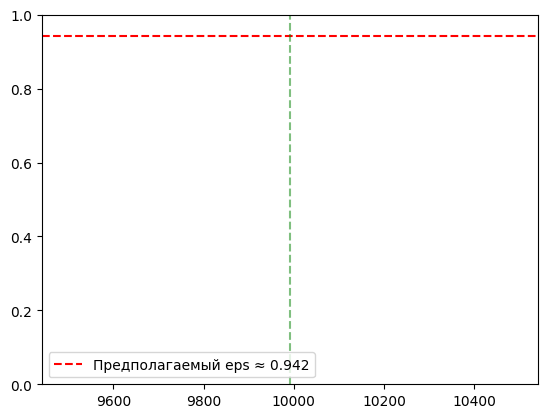

In [35]:
distances_diff = np.diff(k_distances)
if len(distances_diff) > 1:
    distances_diff2 = np.diff(distances_diff)
    if len(distances_diff2) > 0:
        elbow_idx = np.argmax(distances_diff2) + 2
    else:
        elbow_idx = len(k_distances) // 10  # Запасной вариант
else:
    elbow_idx = len(k_distances) // 10

eps_candidate = k_distances[elbow_idx]
plt.axhline(y=eps_candidate, color='r', linestyle='--', 
            label=f'Предполагаемый eps ≈ {eps_candidate:.3f}')
plt.axvline(x=elbow_idx, color='g', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Быстрое тестирование параметров НА ПОДВЫБОРКЕ

Тестируем eps=0.471, min_samples=30...
Тестируем eps=0.942, min_samples=50...
Тестируем eps=1.413, min_samples=50...
Тестируем eps=1.884, min_samples=70...


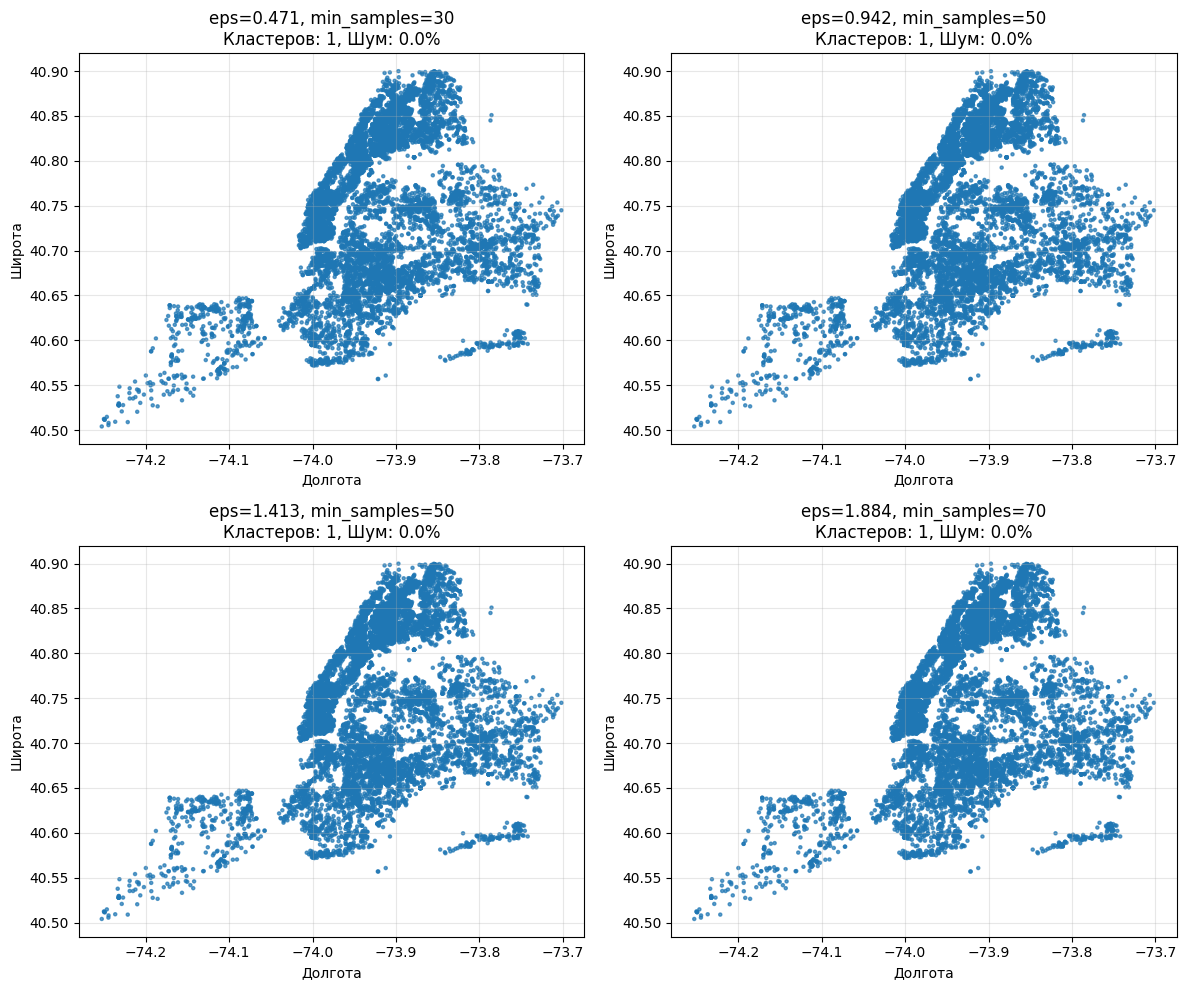

In [36]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

param_combinations = [
    {'eps': max(0.01, eps_candidate * 0.5), 'min_samples': 30},
    {'eps': eps_candidate, 'min_samples': 50},
    {'eps': eps_candidate * 1.5, 'min_samples': 50},
    {'eps': eps_candidate * 2, 'min_samples': 70},
]

results_dbscan = []

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, params in enumerate(param_combinations):
    eps_val = params['eps']
    min_samples_val = params['min_samples']
    
    print(f"Тестируем eps={eps_val:.3f}, min_samples={min_samples_val}...")
    
    # Применяем DBSCAN ТОЛЬКО на подвыборке
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val, metric='euclidean', n_jobs=-1)
    dbscan_labels = dbscan.fit_predict(X_sample)
    
    # Анализ результатов
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = sum(dbscan_labels == -1)
    noise_percentage = n_noise / len(dbscan_labels) * 100
    
    # Silhouette score (только если есть кластеры)
    if n_clusters > 1:
        mask = dbscan_labels != -1
        if sum(mask) > 1:
            try:
                silhouette_val = silhouette_score(X_sample[mask], dbscan_labels[mask])
            except:
                silhouette_val = -1
        else:
            silhouette_val = -1
    else:
        silhouette_val = -1
    
    results_dbscan.append({
        'eps': eps_val,
        'min_samples': min_samples_val,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_percent': noise_percentage,
        'silhouette': silhouette_val
    })
    
    # Визуализация
    scatter = axes[idx].scatter(df_clean.iloc[sample_indices]['Longitude'].values, 
                                df_clean.iloc[sample_indices]['Latitude'].values, 
                                c=dbscan_labels, cmap='tab20', s=5, alpha=0.7)
    axes[idx].set_xlabel('Долгота')
    axes[idx].set_ylabel('Широта')
    axes[idx].set_title(f'eps={eps_val:.3f}, min_samples={min_samples_val}\n'
                       f'Кластеров: {n_clusters}, Шум: {noise_percentage:.1f}%')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
results_df = pd.DataFrame(results_dbscan)
print("\nРезультаты быстрого тестирования на подвыборке:")
print(results_df.to_string(index=False))

valid_results = results_df[results_df['silhouette'] > 0]
if not valid_results.empty:
    best_idx = valid_results['silhouette'].idxmax()
    best_params = results_df.loc[best_idx]
    print(f"\n✓ Лучшие параметры: eps={best_params['eps']:.3f}, min_samples={best_params['min_samples']}")
    print(f"  Silhouette: {best_params['silhouette']:.4f}, Кластеров: {best_params['n_clusters']}")
else:
    best_idx = results_df['n_clusters'].idxmax()
    best_params = results_df.loc[best_idx]
    print(f"\n⚠ Нет валидных silhouette scores")
    print(f"  Выбираем: eps={best_params['eps']:.3f}, min_samples={best_params['min_samples']}")
    print(f"  Кластеров: {best_params['n_clusters']}, Шум: {best_params['noise_percent']:.1f}%")


Результаты быстрого тестирования на подвыборке:
     eps  min_samples  n_clusters  n_noise  noise_percent  silhouette
0.470935           30           1        0            0.0          -1
0.941869           50           1        0            0.0          -1
1.412804           50           1        0            0.0          -1
1.883739           70           1        0            0.0          -1

⚠ Нет валидных silhouette scores
  Выбираем: eps=0.471, min_samples=30.0
  Кластеров: 1.0, Шум: 0.0%


In [ ]:
# 4. Выбираем лучшие параметры на основе silhouette score
# Фильтруем результаты с валидным silhouette score
valid_results = results_df[results_df['silhouette'] > 0]

if not valid_results.empty:
    best_params_idx = valid_results['silhouette'].idxmax()
    best_params = results_df.loc[best_params_idx]
else:
    # Если нет валидных silhouette scores, выбираем по количеству кластеров
    print("Нет валидных silhouette scores. Выбираем параметры с умеренным количеством кластеров...")
    # Ищем параметры с 3-10 кластерами
    moderate_clusters = results_df[results_df['n_clusters'].between(3, 10)]
    if not moderate_clusters.empty:
        best_params_idx = moderate_clusters['noise_percent'].idxmin()  # Минимальный шум
        best_params = results_df.loc[best_params_idx]
    else:
        # Если ничего не подходит, берем первый вариант
        best_params = results_df.iloc[0]

print("\nЛучшие параметры DBSCAN:")
print(f"eps = {best_params['eps']:.3f}")
print(f"min_samples = {int(best_params['min_samples'])}")
print(f"Ожидаемое количество кластеров: {int(best_params['n_clusters'])}")
print(f"Ожидаемый процент шума: {best_params['noise_percent']:.1f}%")
if best_params['silhouette'] > 0:
    print(f"Silhouette Score: {best_params['silhouette']:.4f}")
else:
    print("Silhouette Score: не вычислен (мало кластеров)")

# 5. Финальная кластеризация с лучшими параметрами
print("\nВыполняем финальную кластеризацию DBSCAN...")
final_dbscan = DBSCAN(eps=best_params['eps'], 
                      min_samples=int(best_params['min_samples']),
                      metric='euclidean')
df_clean['dbscan_cluster'] = final_dbscan.fit_predict(X_scaled)

# Анализ результатов
print("\nСтатистика кластеризации DBSCAN:")
print(f"Всего точек: {len(df_clean)}")
print(f"Точек в кластерах: {sum(df_clean['dbscan_cluster'] != -1)}")
print(f"Шумовых точек: {sum(df_clean['dbscan_cluster'] == -1)}")
print(f"Процент шума: {sum(df_clean['dbscan_cluster'] == -1)/len(df_clean)*100:.1f}%")

# Подсчет кластеров
unique_clusters = set(df_clean['dbscan_cluster'])
n_clusters_final = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
print(f"Количество кластеров: {n_clusters_final}")

# Размеры кластеров
if n_clusters_final > 0:
    print("\nРазмеры кластеров:")
    cluster_sizes = df_clean[df_clean['dbscan_cluster'] != -1]['dbscan_cluster'].value_counts()
    for cluster_id, size in cluster_sizes.sort_index().items():
        percentage = size / len(df_clean) * 100
        print(f"  Кластер {cluster_id}: {size} точек ({percentage:.1f}%)")

Нет валидных silhouette scores. Выбираем параметры с умеренным количеством кластеров...

Лучшие параметры DBSCAN:
eps = 0.471
min_samples = 30
Ожидаемое количество кластеров: 1
Ожидаемый процент шума: 0.0%
Silhouette Score: не вычислен (мало кластеров)

Выполняем финальную кластеризацию DBSCAN...
